In [1]:
import numpy as np
import torch
from PIL import Image
import torch.nn as nn
import torch.nn.functional as Func
import torch.optim as optim
from PIL import Image
import os
import random
import torchvision
#import torchmetrics
import torchvision.transforms as transforms
import kagglehub
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
from torch.utils.data import ConcatDataset


In [2]:
# Download latest version
path = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Alexa\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2


# Import af data

## Overblik over dataet

In [3]:
random.seed(42) # Sætter randomseed for datasplittelse.
ai_images_path = os.path.join(path + '/real_vs_fake/real-vs-fake/train/fake')
real_images_path = os.path.join(path + '/real_vs_fake/real-vs-fake/train/real')

#image_files = [f for f in os.listdir(real_images_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

image_files_real = []
for i in os.listdir(real_images_path):
    if i.endswith(('.png', '.jpg', '.jpeg')):
        image_files_real.append(i)

image_files_real = image_files_real[:30800]

random.shuffle(image_files_real)

print(image_files_real)
print(len(image_files_real))

['26288.jpg', '31931.jpg', '10828.jpg', '26931.jpg', '14811.jpg', '07423.jpg', '04298.jpg', '13153.jpg', '23045.jpg', '30714.jpg', '20174.jpg', '41718.jpg', '06046.jpg', '30324.jpg', '22175.jpg', '19989.jpg', '16543.jpg', '41901.jpg', '02653.jpg', '12505.jpg', '13862.jpg', '00678.jpg', '16215.jpg', '21917.jpg', '10635.jpg', '37358.jpg', '02825.jpg', '34438.jpg', '08017.jpg', '06519.jpg', '31144.jpg', '37270.jpg', '19288.jpg', '29927.jpg', '06763.jpg', '01617.jpg', '28082.jpg', '30800.jpg', '27696.jpg', '19383.jpg', '00318.jpg', '40517.jpg', '20238.jpg', '37330.jpg', '29201.jpg', '27044.jpg', '27208.jpg', '30536.jpg', '35455.jpg', '07183.jpg', '36026.jpg', '33139.jpg', '41215.jpg', '41641.jpg', '24320.jpg', '24807.jpg', '38705.jpg', '01288.jpg', '26301.jpg', '27977.jpg', '33990.jpg', '02344.jpg', '16786.jpg', '15012.jpg', '13601.jpg', '26808.jpg', '23203.jpg', '18745.jpg', '16713.jpg', '07764.jpg', '05751.jpg', '33555.jpg', '09616.jpg', '27833.jpg', '30704.jpg', '09641.jpg', '28208.jpg'

In [4]:
random.seed(42) # Sætter randomseed for datasplittelse.
image_files_GAN = []
for i in os.listdir(ai_images_path):
    if i.endswith(('.png', '.jpg', '.jpeg')):
        image_files_GAN.append(i)

image_files_GAN = image_files_GAN[:15400]

random.shuffle(image_files_GAN)

print("Found images:", image_files_GAN)
print(len(image_files_GAN))

Found images: ['9CQRYH0BOB.jpg', '1KZLH39CCI.jpg', '0TVYLSU0FS.jpg', '6JIKOYZ9JP.jpg', '0PZI6DJ4IH.jpg', '4STL0OFI7I.jpg', '9C8JWMUQ70.jpg', '2EOYODZTJ1.jpg', '5KUMTCL98V.jpg', '1ZPFBMA2HX.jpg', '6QWIQAOQ1Z.jpg', '3MTOMLPJBW.jpg', '5EAP4WGYRH.jpg', '6D38LSRGYO.jpg', '8QB6LWN6XH.jpg', '2HT5SWXO00.jpg', '2TIRRZA7ZP.jpg', '0YUFS39YPJ.jpg', '9113B18HI3.jpg', '733221R7EN.jpg', '7TSQOSUR2R.jpg', '3NZ5GSX1AA.jpg', '7FEOIK1NGV.jpg', '1LAXMSFBX6.jpg', '4FMEZ1ZRJF.jpg', '98DSMBANNP.jpg', '4P4DAXSAD1.jpg', '200UMQN7VL.jpg', '7GR280CASJ.jpg', '5WZJZ9HWFX.jpg', '95S0XH1YJ3.jpg', '63UCLBXFK7.jpg', '740WSBZUGU.jpg', '50WU2XEEEB.jpg', '3UOOSRETLM.jpg', '57YWQBYACD.jpg', '3SQ98I52DO.jpg', '18HP84I59I.jpg', '9DYXQVXHF2.jpg', '5TWH2LCWYC.jpg', '8YSU91CSUX.jpg', '3QCA1FRAL6.jpg', '9Z76HNQT8V.jpg', '4AB6HUCGJM.jpg', '7RVM5NSJ80.jpg', '2E0UREPD23.jpg', 'A0CEGQOYSG.jpg', '4FO2Z0TH6X.jpg', '93VRAIJGVA.jpg', '23PB0KR9MY.jpg', 'AFK5PK9YCE.jpg', '3VE5HTT3XY.jpg', '9B8DTVQPXB.jpg', '8A6OFAFRG4.jpg', '96IS5Q5WJZ.j

## Lave en liste over paths til hver billede

In [5]:
all_real_images = []

for filename in image_files_real:
    all_real_images.append(os.path.join(real_images_path, filename))

all_GAN_images = []

for filename in image_files_GAN:
    all_GAN_images.append(os.path.join(ai_images_path, filename))

#all_ai_images.append(ai_images_path + "/" + filename)

print(len(all_GAN_images))
print(len(all_real_images))

#image = plt.imread(all_ai_images[0])
#plt.imshow(image)
print(all_GAN_images[0])


15400
30800
C:\Users\Alexa\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2/real_vs_fake/real-vs-fake/train/fake\9CQRYH0BOB.jpg


### IMPORT af stable diffusion billeder

In [6]:
random.seed(42) # Sætter randomseed for datasplittelse.
stable_diffusion_path = r"C:\Users\Alexa\Desktop\Kode til skolen\MIdjourney AI faces"
image_files_stableDiffusion = []


for i in os.listdir(stable_diffusion_path):
    if i.endswith(('.png', '.jpg', '.jpeg')):
        image_files_stableDiffusion.append(os.path.join(stable_diffusion_path,i))

print(len(image_files_stableDiffusion))

random.shuffle(image_files_stableDiffusion)

print(image_files_stableDiffusion[0])

15400
C:\Users\Alexa\Desktop\Kode til skolen\MIdjourney AI faces\01103-4170523832.png


#### DATASPLIT

In [7]:
# DATA SPLIT FOR GAN:
training_size_GAN = int(0.70 * len(all_GAN_images))
validation_size_GAN = int(0.15 * len(all_GAN_images))
test_size_GAN = len(all_GAN_images) - training_size_GAN - validation_size_GAN

# Create the splits
training_data_GAN = all_GAN_images[:training_size_GAN]
validation_data_GAN = all_GAN_images[training_size_GAN:training_size_GAN + validation_size_GAN]
test_data_GAN = all_GAN_images[training_size_GAN + validation_size_GAN:]

# Print results to verify
print("Training Data GAN:", len(training_data_GAN))
print("Validation Data GAN:", len(validation_data_GAN))
print("Test Data GAN:", len(test_data_GAN))

#########################################################################################################################

# DATA SPLIT FOR STABLE DIFFUSION IMAGES
training_size_sd = int(0.70 * len(image_files_stableDiffusion))
validation_size_sd = int(0.15 * len(image_files_stableDiffusion))
test_size_sd = len(image_files_stableDiffusion) - training_size_sd - validation_size_sd

# Create the splits
training_data_sd = image_files_stableDiffusion[:training_size_sd]
validation_data_sd = image_files_stableDiffusion[training_size_sd:training_size_sd + validation_size_sd]
test_data_sd = image_files_stableDiffusion[training_size_sd + validation_size_sd:]

# Print results to verify
print("Stable Diffusion Training Data:", len(training_data_sd))
print("Stable Diffusion Validation Data:", len(validation_data_sd))
print("Stable Diffusion Test Data:", len(test_data_sd))



#####################################################################################################################

# DATA SPLIT FOR REAL IMAGES
training_size_real = int(0.70 * len(all_real_images))
validation_size_real = int(0.15 * len(all_real_images))
test_size_real = len(all_real_images) - training_size_real - validation_size_real

# Create the splits
training_data_real = all_real_images[:training_size_real]
validation_data_real = all_real_images[training_size_real:training_size_real + validation_size_real]


midpoint = len(validation_data_real) // 2
validation_data_real_stable = validation_data_real[:midpoint]  # First half
validation_data_real_GAN = validation_data_real[midpoint:]     # Second half

test_data_real = all_real_images[training_size_real + validation_size_real:]

midpoint_test = len(test_data_real) // 2
test_data_real_stable = test_data_real[:midpoint_test]  # First half
test_data_real_GAN = test_data_real[midpoint_test:]     # Second half



# Print results to verify
print("Real Images Training Data:", len(training_data_real))
print("Real Images Validation Data for GAN:", len(validation_data_real_GAN))
print("Real Images Validation Data for stable:", len(validation_data_real_stable))
print("Real Images Test Data for GAN:", len(test_data_real_GAN))
print("Real Images Test Data for stable:", len(test_data_real_stable))


Training Data GAN: 10780
Validation Data GAN: 2310
Test Data GAN: 2310
Stable Diffusion Training Data: 10780
Stable Diffusion Validation Data: 2310
Stable Diffusion Test Data: 2310
Real Images Training Data: 21560
Real Images Validation Data for GAN: 2310
Real Images Validation Data for stable: 2310
Real Images Test Data for GAN: 2310
Real Images Test Data for stable: 2310


In [8]:
# Labels for Stable Diffusion Data (Fake Images)
stable_diffusion_train_labels = torch.zeros(len(training_data_sd))  # Fake: 0
stable_diffusion_val_labels = torch.zeros(len(validation_data_sd))
stable_diffusion_test_labels = torch.zeros(len(test_data_sd))

# Labels for GAN Data (Fake Images)
gan_train_labels = torch.zeros(len(training_data_GAN))  # Fake: 0
gan_val_labels = torch.zeros(len(validation_data_GAN))
gan_test_labels = torch.zeros(len(test_data_GAN))

# Labels for Real Images Data for GAN
real_images_train_labels = torch.ones(len(training_data_real))  # Real: 1
real_images_val_labels_GAN = torch.ones(len(validation_data_real_GAN))  # Real: 1
real_images_test_labels_GAN = torch.ones(len(test_data_real_GAN))  # Real: 1

# Labels for Real Images Data for Stable Diffusion
real_images_val_labels_stable = torch.ones(len(validation_data_real_stable))  # Real: 1
real_images_test_labels_stable = torch.ones(len(test_data_real_stable))  # Real: 1

# Print to verify all labels
print("Stable Diffusion Training Labels Shape:", stable_diffusion_train_labels.shape)
print("Stable Diffusion Validation Labels Shape:", stable_diffusion_val_labels.shape)
print("Stable Diffusion Test Labels Shape:", stable_diffusion_test_labels.shape)

print("GAN Training Labels Shape (Fake):", gan_train_labels.shape)
print("GAN Validation Labels Shape (Fake):", gan_val_labels.shape)
print("GAN Test Labels Shape (Fake):", gan_test_labels.shape)

print("Real Images Training Labels Shape:", real_images_train_labels.shape)
print("Real Images Validation Labels for GAN Shape:", real_images_val_labels_GAN.shape)
print("Real Images Test Labels for GAN Shape:", real_images_test_labels_GAN.shape)

print("Real Images Validation Labels for Stable Shape:", real_images_val_labels_stable.shape)
print("Real Images Test Labels for Stable Shape:", real_images_test_labels_stable.shape)

print(real_images_val_labels_stable)

Stable Diffusion Training Labels Shape: torch.Size([10780])
Stable Diffusion Validation Labels Shape: torch.Size([2310])
Stable Diffusion Test Labels Shape: torch.Size([2310])
GAN Training Labels Shape (Fake): torch.Size([10780])
GAN Validation Labels Shape (Fake): torch.Size([2310])
GAN Test Labels Shape (Fake): torch.Size([2310])
Real Images Training Labels Shape: torch.Size([21560])
Real Images Validation Labels for GAN Shape: torch.Size([2310])
Real Images Test Labels for GAN Shape: torch.Size([2310])
Real Images Validation Labels for Stable Shape: torch.Size([2310])
Real Images Test Labels for Stable Shape: torch.Size([2310])
tensor([1., 1., 1.,  ..., 1., 1., 1.])


# Databehandling

## Transformering af data

##### DEFINERE TRANSFORMATIONERNE

In [9]:
train_data_transform = transforms.Compose([
transforms.Resize(size = (144,144)),
transforms.RandomRotation((-45,45)),
transforms.RandomHorizontalFlip(p=0.5),
transforms.ColorJitter(
    brightness=(0.9, 1.1),    # Små ændringer i lysstyrke
    contrast=(0.9, 1.1),      # Små ændringer i kontrast
    saturation=(0.95, 1.05),  # Små ændringer i mætning
    hue=(-0.05, 0.05)),         # Minimal nuanceændring
transforms.ToTensor()
])

val_data_transform = transforms.Compose([
transforms.Resize(size = (144,144)),
transforms.ToTensor()
])

In [10]:
# Transform Training Data
training_data_GAN_transformed = [train_data_transform(Image.open(img_path)) for img_path in training_data_GAN]
training_data_sd_transformed = [train_data_transform(Image.open(img_path)) for img_path in training_data_sd]
training_data_real_transformed = [train_data_transform(Image.open(img_path)) for img_path in training_data_real]

# Transform Validation Data
validation_data_GAN_transformed = [val_data_transform(Image.open(img_path)) for img_path in validation_data_GAN]
validation_data_sd_transformed = [val_data_transform(Image.open(img_path)) for img_path in validation_data_sd]
validation_data_real_stable_transformed = [
    val_data_transform(Image.open(img_path)) for img_path in validation_data_real_stable
]
validation_data_real_GAN_transformed = [
    val_data_transform(Image.open(img_path)) for img_path in validation_data_real_GAN
]

# Transform Test Data
test_data_GAN_transformed = [val_data_transform(Image.open(img_path)) for img_path in test_data_GAN]
test_data_sd_transformed = [val_data_transform(Image.open(img_path)) for img_path in test_data_sd]
test_data_real_stable_transformed = [val_data_transform(Image.open(img_path)) for img_path in test_data_real_stable]
test_data_real_GAN_transformed = [val_data_transform(Image.open(img_path)) for img_path in test_data_real_GAN]

# Print Verification
print("Transformed Training Data GAN:", len(training_data_GAN_transformed))
print("Transformed Training Data SD:", len(training_data_sd_transformed))
print("Transformed Training Data Real:", len(training_data_real_transformed))

print("Transformed Validation Data GAN:", len(validation_data_GAN_transformed))
print("Transformed Validation Data SD:", len(validation_data_sd_transformed))
print("Transformed Validation Data Real Stable:", len(validation_data_real_stable_transformed))
print("Transformed Validation Data Real GAN:", len(validation_data_real_GAN_transformed))

print("Transformed Test Data GAN:", len(test_data_GAN_transformed))
print("Transformed Test Data SD:", len(test_data_sd_transformed))
print("Transformed Test Data Real Stable:", len(test_data_real_stable_transformed))
print("Transformed Test Data Real GAN:", len(test_data_real_GAN_transformed))


Transformed Training Data GAN: 10780
Transformed Training Data SD: 10780
Transformed Training Data Real: 21560
Transformed Validation Data GAN: 2310
Transformed Validation Data SD: 2310
Transformed Validation Data Real Stable: 2310
Transformed Validation Data Real GAN: 2310
Transformed Test Data GAN: 2310
Transformed Test Data SD: 2310
Transformed Test Data Real Stable: 2310
Transformed Test Data Real GAN: 2310


In [11]:

print(torch.stack(training_data_sd_transformed).shape)
print(stable_diffusion_train_labels.shape)

torch.Size([10780, 3, 144, 144])
torch.Size([10780])


### CHECK BILLEDER

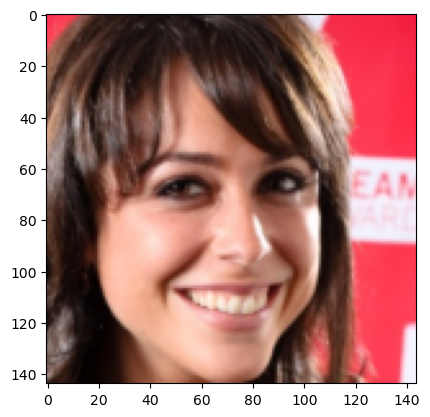

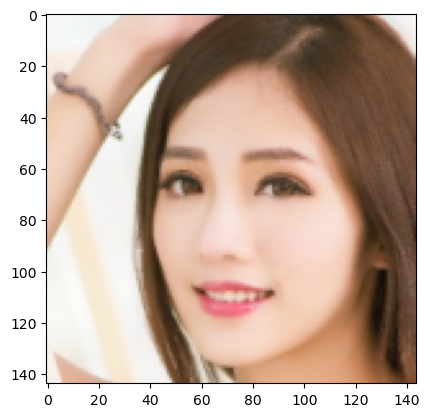

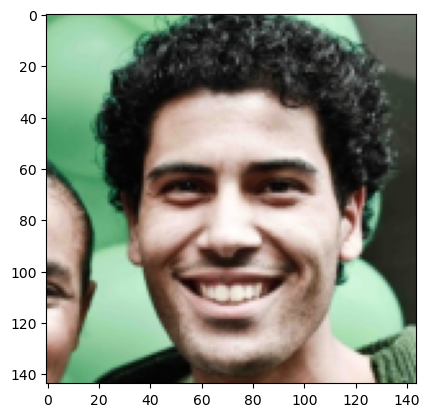

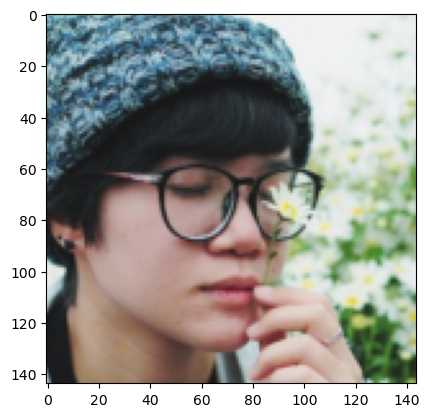

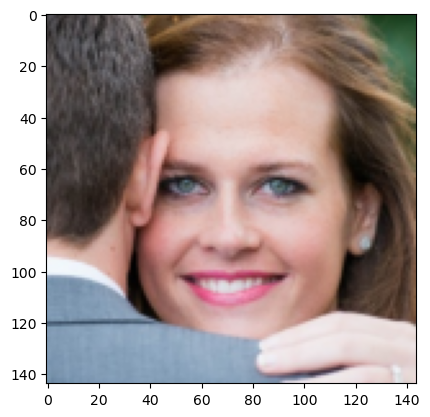

In [12]:
for i in range(5):
    to_pil = transforms.ToPILImage()
    normal_image = to_pil(validation_data_real_stable_transformed[i])

    # Display the converted image
    plt.imshow(normal_image)
    plt.show()



### lave om til tensordataset

In [13]:
# Stable Diffusion Datasets (Fake Images)
stable_diffusion_train_dataset = TensorDataset(torch.stack(training_data_sd_transformed), stable_diffusion_train_labels)
stable_diffusion_val_dataset = TensorDataset(torch.stack(validation_data_sd_transformed), stable_diffusion_val_labels)
stable_diffusion_test_dataset = TensorDataset(torch.stack(test_data_sd_transformed), stable_diffusion_test_labels)

# GAN Datasets (Fake Images)
gan_train_dataset = TensorDataset(torch.stack(training_data_GAN_transformed), gan_train_labels)
gan_val_dataset = TensorDataset(torch.stack(validation_data_GAN_transformed), gan_val_labels)
gan_test_dataset = TensorDataset(torch.stack(test_data_GAN_transformed), gan_test_labels)

# Real Images Datasets for GAN
real_images_train_dataset = TensorDataset(torch.stack(training_data_real_transformed), real_images_train_labels)
real_images_val_dataset_gan = TensorDataset(torch.stack(validation_data_real_GAN_transformed), real_images_val_labels_GAN)
real_images_test_dataset_gan = TensorDataset(torch.stack(test_data_real_GAN_transformed), real_images_test_labels_GAN)

# Real Images Datasets for Stable Diffusion
real_images_val_dataset_stable = TensorDataset(torch.stack(validation_data_real_stable_transformed), real_images_val_labels_stable)
real_images_test_dataset_stable = TensorDataset(torch.stack(test_data_real_stable_transformed), real_images_test_labels_stable)

# Print to verify TensorDataset creation
print("Stable Diffusion Train Dataset:", len(stable_diffusion_train_dataset))
print("Stable Diffusion Validation Dataset:", len(stable_diffusion_val_dataset))
print("Stable Diffusion Test Dataset:", len(stable_diffusion_test_dataset))

print("GAN Train Dataset:", len(gan_train_dataset))
print("GAN Validation Dataset:", len(gan_val_dataset))
print("GAN Test Dataset:", len(gan_test_dataset))

print("Real Images Train Dataset:", len(real_images_train_dataset))
print("Real Images Validation Dataset for GAN:", len(real_images_val_dataset_gan))
print("Real Images Test Dataset for GAN:", len(real_images_test_dataset_gan))

print("Real Images Validation Dataset for Stable:", len(real_images_val_dataset_stable))
print("Real Images Test Dataset for Stable:", len(real_images_test_dataset_stable))


Stable Diffusion Train Dataset: 10780
Stable Diffusion Validation Dataset: 2310
Stable Diffusion Test Dataset: 2310
GAN Train Dataset: 10780
GAN Validation Dataset: 2310
GAN Test Dataset: 2310
Real Images Train Dataset: 21560
Real Images Validation Dataset for GAN: 2310
Real Images Test Dataset for GAN: 2310
Real Images Validation Dataset for Stable: 2310
Real Images Test Dataset for Stable: 2310


In [14]:
training_dataset = ConcatDataset([
    gan_train_dataset,
    stable_diffusion_train_dataset,
    real_images_train_dataset
])

# Merge Validation Datasets
validation_dataset_GAN = ConcatDataset([
    gan_val_dataset,
    real_images_val_dataset_gan
])

validation_dataset_StableDiffusion = ConcatDataset([
    stable_diffusion_val_dataset,
    real_images_val_dataset_stable
])

# Merge Test Datasets
test_dataset_GAN = ConcatDataset([
    gan_test_dataset,
    real_images_test_dataset_gan
])

test_dataset_StableDiffusion = ConcatDataset([
    stable_diffusion_test_dataset,
    real_images_test_dataset_stable
])

# Print the lengths of the merged datasets for verification
print("Training Dataset Size:", len(training_dataset))
print("Validation Dataset GAN Size:", len(validation_dataset_GAN))
print("Validation Dataset Stable Diffusion Size:", len(validation_dataset_StableDiffusion))
print("Test Dataset GAN Size:", len(test_dataset_GAN))
print("Test Dataset Stable Diffusion Size:", len(test_dataset_StableDiffusion))


Training Dataset Size: 43120
Validation Dataset GAN Size: 4620
Validation Dataset Stable Diffusion Size: 4620
Test Dataset GAN Size: 4620
Test Dataset Stable Diffusion Size: 4620


## Loading af data

In [15]:
training_loader = DataLoader(training_dataset,batch_size=32,shuffle=True)

validation_loader_GAN= DataLoader(validation_dataset_GAN,batch_size=32,shuffle=False)
validation_loader_StableDiffusion= DataLoader(validation_dataset_StableDiffusion,batch_size=32,shuffle=False)

test_loader_GAN = DataLoader(test_dataset_GAN,batch_size=32,shuffle=False)
test_loader_StableDiffusion = DataLoader(test_dataset_StableDiffusion,batch_size=32,shuffle=False)

# Modellen

In [53]:
def model_structure():
  model = torch.nn.Sequential(
      nn.Conv2d(3,32,3),
      nn.ReLU(),
      nn.MaxPool2d(2,2),
      nn.Conv2d(32,64,3),
      nn.ReLU(),
      nn.MaxPool2d(2,2),
      nn.Conv2d(64,128,3),
      nn.ReLU(),
      nn.MaxPool2d(2,2),
      nn.Conv2d(128,256,3),
      nn.ReLU(),
      nn.MaxPool2d(2,2),
      nn.Flatten(),
      nn.Linear(12544,256),
      nn.ReLU(),
      nn.Linear(256,1),
      nn.Sigmoid()
  )
  return model

In [54]:
model_structure()
model = model_structure()

In [40]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

Total number of parameters: 3600193


## Udregning til brug i modellen

In [41]:
x = torch.randn(1, 3, 144, 144)  # Dummy input
conv_output = model(x)  # Extract layers up to Flatten
print(conv_output.shape)  # Ensure it's (batch_size, 34848)

torch.Size([1, 1])


In [42]:
input_tensor = torch.randn(1, 3, 144, 144)

conv = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)

output_tensor = conv(input_tensor)

print(output_tensor.shape)

torch.Size([1, 32, 142, 142])


# Loss funktion

In [55]:
loss_function = nn.BCELoss() # Binary cross entropy
weight_decay = 0.0001

learning_rate = 0.0001

device = torch.device("cuda")
model.to(device)

def loss_testing(learning_rate,device): 

   optimizer = optim.Adam(model.parameters(), lr=learning_rate)
   model.to(device)
 
 # accuracy_metric = torchmetrics.classification.BinaryAccuracy(threshold=0.5, multidim_average='global', ignore_index=None, validate_args=True)


   return optimizer


In [56]:
loss_testing(learning_rate,device)
optimizer = loss_testing(learning_rate,device)


# Epochs - træningen

In [57]:
def training(loss_function, optimizer, device, validation_loader_StableDiffusion,validation_loader_GAN, training_loader):
    epochs = 50

    train_loss_list = []
    val_loss_list_GAN = []
    val_loss_list_stable = []

    train_acc = []
    val_acc_GAN = []
    val_acc_stable = []

    optimized_acc = 0
    batch_counter = 0

    for epoch in range(epochs):
        print(f"Training Epoch.... {epoch}")
        train_loss_løbende = 0
        val_loss_løbende_stable = 0
        val_loss_løbende_GAN = 0

        # STARTE MED AT VALIDERE MODELLEN INDEN DEN BLIVER TRÆNET FOR BEGGE VALIDERINGSÆT
        # FINDER BÅDE ACCURACY OG LØBENDE LOSS
        correct=0
        false=0

        # FOR STABLE DIFFUSION
        with torch.no_grad():
            for batch in validation_loader_StableDiffusion:
                billede_tensor, label = batch
                billede_tensor = billede_tensor.to(device) # Move input to GPU or CPU
                label = label.to(device)
                label = label.float() # Man skal have samme data type
                label_pred = model(billede_tensor) # Forventningen om det er AI eller ægte billede, ud fra modellen der er lavet
                label_pred = label_pred.squeeze(dim=1)
                loss = loss_function(label_pred, label)
                val_loss_løbende_stable +=loss.item()
                # BEREGNER ACCURACY
                for i,pred in enumerate(label_pred):
                    if round(float(pred))==round(float(label[i])):
                        correct+=1
                    else:
                        false+=1
            print(f"val_stable done at epoch {epoch}")
            # tilføjer loss løbende og accuracy for stable_diffusion, loss_løbende delt med antallet af batches så vi får et per batch loss ( nemmere og sammenligne på tværs af dataloaders)
            val_loss_list_stable.append(val_loss_løbende_stable/len(validation_loader_StableDiffusion))
            val_acc_stable.append((correct)/(correct+false))

            correct=0
            false=0

            # FOR styleGAN
            for batch in validation_loader_GAN:
                billede_tensor, label = batch
                billede_tensor = billede_tensor.to(device) # Move input to GPU
                label = label.to(device)
                label = label.float() # Man skal have samme data type
                label_pred = model(billede_tensor) # Forventningen om det er AI eller ægte billede, ud fra modellen der er lavet
                label_pred = label_pred.squeeze(dim=1)
                loss = loss_function(label_pred, label)
                val_loss_løbende_GAN +=loss.item()
                for i,pred in enumerate(label_pred):
                    if round(float(pred))==round(float(label[i])):
                        correct+=1
                    else:
                        false+=1
            val_acc_GAN.append((correct)/(correct+false))
            val_loss_list_GAN.append(val_loss_løbende_GAN/len(validation_loader_GAN))

            print(f"val_GAN done at epoch {epoch}")

            correct=0
            false=0

        for i,batch in enumerate(training_loader):
            billede_tensor, label = batch
            billede_tensor = billede_tensor.to(device) # Move input to GPU
            label = label.to(device)
            label = label.float() # Man skal have samme data type
            label_pred = model(billede_tensor) # Forventningen om det er AI eller ægte billede, ud fra modellen der er lavet
            label_pred = label_pred.squeeze(dim=1)
            loss = loss_function(label_pred, label)
            train_loss_løbende += loss.item()

            optimizer.zero_grad() # Nulstiller gradienten

            loss.backward() # Backward pass: compute gradient of the loss with respect to model parameters

            optimizer.step() # Calling the step function on an Optimizer makes an update to its parameters

            for k,pred in enumerate(label_pred):
                if round(float(pred))==round(float(label[k])):
                    correct+=1
                else:
                    false+=1
            # if i%500==0:
            #  print(f"training batch {i} of {len(training_loader)} is done")
        train_acc.append((correct)/(correct+false))
        train_loss_list.append(train_loss_løbende/len(training_loader))

        mean_acc_loss_stable_and_GAN = (val_acc_GAN[epoch]+val_acc_stable[epoch])/2

        if mean_acc_loss_stable_and_GAN > optimized_acc:
            optimized_acc = mean_acc_loss_stable_and_GAN
            torch.save(model.state_dict(), fr"c:\Users\Alexa\Desktop\Kode til skolen\trained_model{epoch}")
            print(f'Epoch: {epoch} Mean val accuracy: {mean_acc_loss_stable_and_GAN}')


        print(f"LOSS: {train_loss_løbende:.5f}")
    return train_loss_list, val_loss_list_stable, val_loss_list_GAN, train_acc, val_acc_stable, val_acc_GAN, epochs



In [58]:
train_loss_list, val_loss_list_stable, val_loss_list_GAN, train_acc, val_acc_stable, val_acc_GAN, epochs = training(loss_function, optimizer, device, validation_loader_StableDiffusion,validation_loader_GAN, training_loader)

Training Epoch.... 0
val_stable done at epoch 0
val_GAN done at epoch 0
Epoch: 0 Mean val accuracy: 0.5
LOSS: 777.51995
Training Epoch.... 1
val_stable done at epoch 1
val_GAN done at epoch 1
Epoch: 1 Mean val accuracy: 0.7304112554112554
LOSS: 655.71839
Training Epoch.... 2
val_stable done at epoch 2
val_GAN done at epoch 2
Epoch: 2 Mean val accuracy: 0.775974025974026
LOSS: 588.90847
Training Epoch.... 3
val_stable done at epoch 3
val_GAN done at epoch 3
Epoch: 3 Mean val accuracy: 0.8008658008658008
LOSS: 540.30480
Training Epoch.... 4
val_stable done at epoch 4
val_GAN done at epoch 4
Epoch: 4 Mean val accuracy: 0.8114718614718615
LOSS: 499.13088
Training Epoch.... 5
val_stable done at epoch 5
val_GAN done at epoch 5
Epoch: 5 Mean val accuracy: 0.8274891774891775
LOSS: 463.14390
Training Epoch.... 6
val_stable done at epoch 6
val_GAN done at epoch 6
Epoch: 6 Mean val accuracy: 0.8325757575757575
LOSS: 426.03015
Training Epoch.... 7
val_stable done at epoch 7
val_GAN done at epoch 7

In [59]:
print(len(epochs_list))
print(len(train_loss_list))
print(len(val_loss_list_stable))
print(len(val_loss_list_GAN))

50
50
50
50


### Middelværdi for validation loss af de to modeller + Middelværdi for accuracy for de to modeller

In [60]:
#print(val_loss_list_GAN)

#print(val_loss_list_stable)

print(f'Train loss minimum {min(train_loss_list)}')
print(f'Træningsaccuracy maximum {max(train_acc)}')
mean_val_loss_stable_and_GAN = (np.array(val_loss_list_GAN)+np.array(val_loss_list_stable))/2
print(f'Middelværdi for validation loss af stable og GAN {min(mean_val_loss_stable_and_GAN)}')

mean_acc_loss_stable_and_GAN = (np.array(val_acc_GAN)+np.array(val_acc_stable))/2
print(f'Middelværdi for validation accuracy af stable og GAN {max(mean_acc_loss_stable_and_GAN )}')

Train loss minimum 0.00233856152887237
Træningsaccuracy maximum 0.999443413729128
Middelværdi for validation loss af stable og GAN 0.3204577656235054
Middelværdi for validation accuracy af stable og GAN 0.8732683982683982


## Grafer

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]


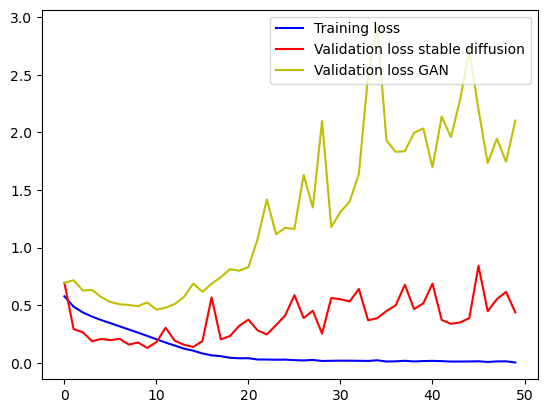

In [61]:
epochs_list=list(range(0,epochs))
print(epochs_list)

plt.plot(epochs_list,train_loss_list,"b",label="Training loss")
plt.plot(epochs_list,val_loss_list_stable,"r",label="Validation loss stable diffusion")
plt.plot(epochs_list,val_loss_list_GAN,"y",label="Validation loss GAN")
plt.legend(loc="upper right")
plt.show()

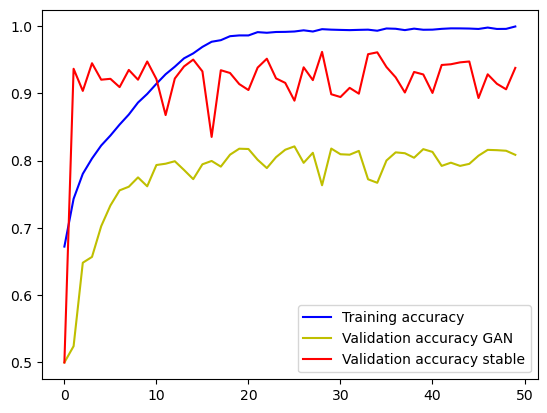

In [62]:
plt.plot(epochs_list,train_acc,"b",label="Training accuracy")
plt.plot(epochs_list,val_acc_GAN,"y",label="Validation accuracy GAN")
plt.plot(epochs_list,val_acc_stable,"r",label="Validation accuracy stable")
plt.legend(loc="lower right")

# Test for at afprøve om det virker på andre billeder end i dataen

In [222]:
def model_tester_structure():
  model_tester = torch.nn.Sequential(
      nn.Conv2d(3,32,3),
      nn.ReLU(),
      nn.MaxPool2d(2,2),
      nn.Conv2d(32,64,3),
      nn.ReLU(),
      nn.MaxPool2d(2,2),
      nn.Conv2d(64,128,3),
      nn.ReLU(),
      nn.MaxPool2d(2,2),
      nn.Conv2d(128,256,3),
      nn.ReLU(),
      nn.MaxPool2d(2,2),
      nn.Flatten(),
      nn.Linear(12544,256),
      nn.ReLU(),
      nn.Linear(256,1),
      nn.Sigmoid()
  )


  model_tester.load_state_dict(torch.load(r"c:\Users\Alexa\Desktop\Kode til skolen\trained_model5", weights_only=True))
  model_tester.eval()
  return model_tester


In [238]:
model_tester = model_tester_structure()

In [224]:
def test_model_accuracy(model, test_loader_GAN, test_loader_StableDiffusion, device):
    # Move model to the specified device
    model = model.to(device)
    model.eval()  # Set the model to evaluation mode

    gan_correct = 0
    gan_total = 0
    sd_correct = 0
    sd_total = 0

    with torch.no_grad():
        for images, labels in test_loader_GAN:
            # Move images and labels to the specified device
            images = images.to(device)
            labels = labels.to(device).float()

            # Forward pass
            outputs = model(images).squeeze(dim=1)
            predicted = (outputs > 0.5).float()

            # Compute accuracy
            gan_total += labels.size(0)
            gan_correct += (predicted == labels).sum().item()

    gan_accuracy = gan_correct / gan_total

    with torch.no_grad():
        for images, labels in test_loader_StableDiffusion:
            # Move images and labels to the specified device
            images = images.to(device)
            labels = labels.to(device).float()

            # Forward pass
            outputs = model(images).squeeze(dim=1)
            predicted = (outputs > 0.5).float()

            # Compute accuracy
            sd_total += labels.size(0)
            sd_correct += (predicted == labels).sum().item()

    sd_accuracy = sd_correct / sd_total
    return gan_accuracy, sd_accuracy


# Testing

In [278]:
import csv

test_runs = 50
gan_accuracy_list = []
sd_accuracy_list = []

for run in range(test_runs):
    model_structure()
    model = model_structure().to(device)  # Move model to the device
    loss_testing(learning_rate,device)
    optimizer= loss_testing(learning_rate,device)
    train_loss_list, val_loss_list_stable, val_loss_list_GAN, train_acc, val_acc_stable, val_acc_GAN, epochs = training(loss_function, optimizer, device, validation_loader_StableDiffusion,validation_loader_GAN, training_loader)
    model_tester_structure()
    model_tester = model_tester_structure().to(device)  # Move model tester to the device
    gan_test_accuracy, sd_test_accuracy = test_model_accuracy(model_tester, test_loader_GAN, test_loader_StableDiffusion, device)
    gan_accuracy_list.append(gan_test_accuracy)
    sd_accuracy_list.append(sd_test_accuracy)

# Save the accuracy lists to a CSV file
with open('accuracy_results.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Run", "GAN Accuracy", "Stable Diffusion Accuracy"])
    for i in range(test_runs):
        writer.writerow([i, gan_accuracy_list[i], sd_accuracy_list[i]])

Training Epoch.... 0
val_stable done at epoch 0
val_GAN done at epoch 0
Epoch: 0 Mean val accuracy: 0.7192640692640693
LOSS: 778.92195
Training Epoch.... 1
val_stable done at epoch 1
val_GAN done at epoch 1
Epoch: 1 Mean val accuracy: 0.7514069264069264
LOSS: 667.97455
Training Epoch.... 2
val_stable done at epoch 2
val_GAN done at epoch 2
Epoch: 2 Mean val accuracy: 0.7931818181818182
LOSS: 594.27788
Training Epoch.... 3
val_stable done at epoch 3
val_GAN done at epoch 3
Epoch: 3 Mean val accuracy: 0.799025974025974
LOSS: 547.98929
Training Epoch.... 4
val_stable done at epoch 4
val_GAN done at epoch 4
Epoch: 4 Mean val accuracy: 0.8113636363636364
LOSS: 514.00479
Training Epoch.... 5
val_stable done at epoch 5
val_GAN done at epoch 5
Epoch: 5 Mean val accuracy: 0.823051948051948
LOSS: 484.75216
Training Epoch.... 6
val_stable done at epoch 6
val_GAN done at epoch 6
Epoch: 6 Mean val accuracy: 0.833982683982684
LOSS: 451.90029
Training Epoch.... 7
val_stable done at epoch 7
val_GAN do